In [1]:
!pip install tensorflow sweetviz ipywidgets openpyxl --quiet

^C


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv
import ipywidgets as widgets
from IPython.display import display, IFrame, clear_output, HTML
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Conv1D, MaxPooling1D, Flatten, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"Imports OK -- TensorFlow {tf.__version__}")
print(f"GPU dispo : {len(tf.config.list_physical_devices('GPU')) > 0}")

Imports OK -- TensorFlow 2.21.0
GPU dispo : False


In [2]:
# Chargement des 8 datasets + 4 fichiers RUL
base_dir = Path(".")   # <- Path("/content/") sur Colab

COLS = ['unit_id', 'cycle',
        'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
       [f'sensor_{i}' for i in range(1, 22)]

RUL_MAX = 125

def add_rul(df):
    max_cycle = df.groupby('unit_id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='unit_id')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_MAX)
    return df.drop(columns='max_cycle')

raw = {}
for split in ['train', 'test']:
    for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
        name = f"{split}_{fd}"
        path = base_dir / f"{name}.xlsx"
        if path.exists():
            df = pd.read_excel(path)
            df.columns = COLS[:df.shape[1]]
            df['source'] = fd
            if split == 'train':
                df = add_rul(df)
            raw[name] = df
            print(f"OK {name:<18} {df.shape[0]:>6} lignes x {df.shape[1]} colonnes")
        else:
            print(f"MANQUANT {name}.xlsx")

rul_raw = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    path = base_dir / f"RUL_{fd}.txt"
    if path.exists():
        vals = pd.read_csv(path, header=None).values.flatten().astype(float)
        rul_raw[fd] = np.minimum(vals, RUL_MAX)
        print(f"OK RUL_{fd}.txt -> {len(vals)} valeurs")
    else:
        print(f"MANQUANT RUL_{fd}.txt")

print(f"\n{len(raw)} datasets + {len(rul_raw)} fichiers RUL charges.")

OK train_FD001         20631 lignes x 28 colonnes
OK train_FD002         53759 lignes x 28 colonnes
OK train_FD003         24720 lignes x 28 colonnes
OK train_FD004         61249 lignes x 28 colonnes
OK test_FD001          13096 lignes x 27 colonnes
OK test_FD002          33991 lignes x 27 colonnes
OK test_FD003          16596 lignes x 27 colonnes
OK test_FD004          41214 lignes x 27 colonnes
OK RUL_FD001.txt -> 100 valeurs
OK RUL_FD002.txt -> 259 valeurs
OK RUL_FD003.txt -> 100 valeurs
OK RUL_FD004.txt -> 248 valeurs

8 datasets + 4 fichiers RUL charges.


In [3]:
# Tableau recapitulatif des datasets C-MAPSS avant le merge
fault_summary = pd.DataFrame([
    {
        'Dataset': 'FD001',
        'Conditions operationnelles': 1,
        'Types de panne': 1,
        'Groupe propose': 'Ligne1 avec FD003',
    },
    {
        'Dataset': 'FD002',
        'Conditions operationnelles': 6,
        'Types de panne': 1,
        'Groupe propose': 'Ligne2 avec FD004',
    },
    {
        'Dataset': 'FD003',
        'Conditions operationnelles': 1,
        'Types de panne': 2,
        'Groupe propose': 'Ligne1 avec FD001',
    },
    {
        'Dataset': 'FD004',
        'Conditions operationnelles': 6,
        'Types de panne': 2,
        'Groupe propose': 'Ligne2 avec FD002',
    },
])

display(fault_summary)

print('Lecture du tableau :')
print('- FD001 et FD003 ont la meme condition operationnelle, mais des types de panne differents.')
print('- FD002 et FD004 ont les memes 6 conditions operationnelles, mais des types de panne differents.')

,Dataset,Conditions operationnelles,Types de panne,Groupe propose
0,FD001,1,1,Ligne1 avec FD003
1,FD002,6,1,Ligne2 avec FD004
2,FD003,1,2,Ligne1 avec FD001
3,FD004,6,2,Ligne2 avec FD002


Lecture du tableau :
- FD001 et FD003 ont la meme condition operationnelle, mais des types de panne differents.
- FD002 et FD004 ont les memes 6 conditions operationnelles, mais des types de panne differents.


La condition opérationnelle correspond au contexte de fonctionnement du moteur au moment où les mesures capteurs sont prises (régime, charge, altitude/vitesse simulée, température ambiante, etc., selon le jeu C-MAPSS).
FD001 et FD003 ont la même condition opérationnelle : les moteurs évoluent dans un seul contexte de fonctionnement.
FD002 et FD004 ont 6 conditions opérationnelles : les moteurs passent par 6 contextes de fonctionnement différents.
Mais types de panne différents.

In [4]:
# Merge des datasets
def merge_train(fd_a, fd_b):
    df_a = raw[f'train_{fd_a}'].copy()
    df_b = raw[f'train_{fd_b}'].copy()
    offset = df_a['unit_id'].max()
    df_b['unit_id'] = df_b['unit_id'] + offset
    return pd.concat([df_a, df_b], ignore_index=True)

def merge_test(fd_a, fd_b):
    df_a = raw[f'test_{fd_a}'].copy()
    df_b = raw[f'test_{fd_b}'].copy()
    offset = df_a['unit_id'].max()
    df_b['unit_id'] = df_b['unit_id'] + offset
    return pd.concat([df_a, df_b], ignore_index=True)

def merge_rul(fd_a, fd_b):
    return np.concatenate([rul_raw[fd_a], rul_raw[fd_b]])

# Ligne 1 : FD001 + FD003
train_Ligne1 = merge_train('FD001', 'FD003')
test_Ligne1  = merge_test('FD001',  'FD003')

rul_Ligne1   = merge_rul('FD001',   'FD003')

# Ligne 2 : FD002 + FD004
train_Ligne2 = merge_train('FD002', 'FD004')
test_Ligne2  = merge_test('FD002',  'FD004')
rul_Ligne2   = merge_rul('FD002',   'FD004')

print("-- Resultat du merge ------------------------------------------")
print(f"  train_Ligne1 (FD001+FD003) : {train_Ligne1.shape[0]:>7} lignes  {train_Ligne1['unit_id'].nunique()} moteurs")
print(f"  test_Ligne1  (FD001+FD003) : {test_Ligne1.shape[0]:>7} lignes  {test_Ligne1['unit_id'].nunique()} moteurs  RUL: {len(rul_Ligne1)} valeurs")
print(f"  train_Ligne2 (FD002+FD004) : {train_Ligne2.shape[0]:>7} lignes  {train_Ligne2['unit_id'].nunique()} moteurs")
print(f"  test_Ligne2  (FD002+FD004) : {test_Ligne2.shape[0]:>7} lignes  {test_Ligne2['unit_id'].nunique()} moteurs  RUL: {len(rul_Ligne2)} valeurs")

datasets_merged = {
    'train_Ligne1 (FD001+FD003)' : train_Ligne1,
    'test_Ligne1  (FD001+FD003)' : test_Ligne1,
    'train_Ligne2 (FD002+FD004)' : train_Ligne2,
    'test_Ligne2  (FD002+FD004)' : test_Ligne2,
}

-- Resultat du merge ------------------------------------------
  train_Ligne1 (FD001+FD003) :   45351 lignes  200 moteurs
  test_Ligne1  (FD001+FD003) :   29692 lignes  200 moteurs  RUL: 200 valeurs
  train_Ligne2 (FD002+FD004) :  115008 lignes  509 moteurs
  test_Ligne2  (FD002+FD004) :   75205 lignes  507 moteurs  RUL: 507 valeurs


In [5]:
# Preparation du jeu merge pour l'entrainement, 
# Ici on choisit la ligne à étudier, prépare X train/test proprement, et harmonise les variables pour que les modèles apprennent correctement

LINE_MAP = {
    'Ligne1': {
        'label': 'FD001+FD003',
        'train': train_Ligne1,
        'test': test_Ligne1,
        'rul_test': rul_Ligne1,
    },
    'Ligne2': {
        'label': 'FD002+FD004',
        'train': train_Ligne2,
        'test': test_Ligne2,
        'rul_test': rul_Ligne2,
    },
}

# Choix du groupe de datasets à utiliser
# Ligne1 = FD001 + FD003
# Ligne2 = FD002 + FD004

LIGNE = 'Ligne1'  # change en 'Ligne2' si besoin
cfg = LINE_MAP[LIGNE]

label = cfg['label']
df_train_m = cfg['train'].copy()
df_test_m = cfg['test'].copy()
y_test_m = cfg['rul_test'].copy()

# Features numeriques utilisees par les modeles
#Sélection des variables d’entrée (features)
#On enlève les colonnes non pertinentes pour le modèle (unit_id, cycle, RUL, source) et on garde uniquement les colonnes numériques dans FEATURE_COLS

EXCLUDE_COLS = {'unit_id', 'cycle', 'RUL', 'source'}
FEATURE_COLS = [
    c for c in df_train_m.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_m[c])
]

# Mise a l'echelle train/test avec le meme scaler, Normalisation des données
# MinMaxScaler met les features entre 0 et 1 :
# fit_transform sur le train (apprend l’échelle),
# transform sur le test (réutilise la même échelle).
# C’est important pour éviter la fuite de données et garder une évaluation correcte.

scaler = MinMaxScaler()
df_train_m[FEATURE_COLS] = scaler.fit_transform(df_train_m[FEATURE_COLS])
df_test_m[FEATURE_COLS] = scaler.transform(df_test_m[FEATURE_COLS])

print(f"Configuration active: {LIGNE} ({label})")
print(f"Train: {df_train_m.shape} | Test: {df_test_m.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:5]}{' ...' if len(FEATURE_COLS) > 5 else ''}")
print(f"y_test_m: {y_test_m.shape}")

Configuration active: Ligne1 (FD001+FD003)
Train: (45351, 28) | Test: (29692, 27)
Features (24): ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2'] ...
y_test_m: (200,)


In [9]:
# Construction des sequences temporelles d'entrainement et de test

#ici l'objectif est d'éviter de lancer l’entraînement avec des données incohérentes.
#on veut que les modèles puissent apprendre à partir de séquences de cycles, plutôt que de points isolés.

SEQ_LEN = 50   # fenetre de 50 cycles

# Validation rapide pour eviter un NameError peu explicite
required_vars = ['df_train_m', 'df_test_m', 'FEATURE_COLS', 'y_test_m']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Variables manquantes: "
        f"{missing_vars}. Execute d'abord la cellule de preparation du jeu merge."
    )

if not FEATURE_COLS:
    raise ValueError("FEATURE_COLS est vide. Verifie la cellule de preparation.")

missing_train_cols = [c for c in FEATURE_COLS if c not in df_train_m.columns]
missing_test_cols = [c for c in FEATURE_COLS if c not in df_test_m.columns]
if missing_train_cols or missing_test_cols:
    raise ValueError(
        "Colonnes features manquantes. "
        f"train manquantes={missing_train_cols}, test manquantes={missing_test_cols}"
    )

if 'RUL' not in df_train_m.columns:
    raise ValueError("La colonne 'RUL' est absente de df_train_m.")

def build_sequences(df, seq_len, feature_cols):
    X_seqs, y_seqs = [], []
    for _, group in df.groupby('unit_id'):
        group    = group.sort_values('cycle')
        features = group[feature_cols].values
        labels   = group['RUL'].values
        for i in range(seq_len, len(features) + 1):
            X_seqs.append(features[i - seq_len : i])
            y_seqs.append(labels[i - 1])
    return np.array(X_seqs), np.array(y_seqs)

def build_test_sequences(df, seq_len, feature_cols):
    X_seqs = []
    for _, group in df.groupby('unit_id'):
        group    = group.sort_values('cycle')
        features = group[feature_cols].values
        if len(features) < seq_len:
            pad      = np.zeros((seq_len - len(features), len(feature_cols)))
            features = np.vstack([pad, features])
        X_seqs.append(features[-seq_len:])
    return np.array(X_seqs)

X_train_m, y_train_m = build_sequences(df_train_m, SEQ_LEN, FEATURE_COLS)
X_test_m              = build_test_sequences(df_test_m, SEQ_LEN, FEATURE_COLS)

print(f"X_train : {X_train_m.shape}  ->  (sequences, {SEQ_LEN} cycles, {len(FEATURE_COLS)} features)")
print(f"y_train : {y_train_m.shape}")
print(f"X_test  : {X_test_m.shape}   ->  (1 sequence par moteur)")
print(f"y_test  : {y_test_m.shape}   ->  RUL vraie au dernier cycle connu")

X_train : (35551, 50, 24)  ->  (sequences, 50 cycles, 24 features)
y_train : (35551,)
X_test  : (200, 50, 24)   ->  (1 sequence par moteur)
y_test  : (200,)   ->  RUL vraie au dernier cycle connu


cette cellule “Construction des séquences temporelles” sert à transformer tes tableaux bruts en format compatible avec les réseaux temporels (LSTM/CNN-LSTM).

Concrètement, elle fait 3 choses :

Créer des fenêtres glissantes pour le train
Pour chaque moteur, elle prend les FEATURE_COLS triées par cycle.
Avec SEQ_LEN = 50, elle fabrique des blocs de forme (50, nb_features).
La cible associée à chaque bloc est la RUL du dernier cycle de la fenêtre.
Résultat: X_train_m et y_train_m.

Préparer le test au bon format
Pour chaque moteur du test, elle garde uniquement la dernière fenêtre de 50 cycles.
Si un moteur a moins de 50 cycles, elle complète avec du padding (zéros).
Résultat: X_test_m (une séquence par moteur).

Garantir que les entrées sont valides
Elle vérifie que les variables nécessaires existent (df_train_m, df_test_m, etc.)
Elle vérifie que les colonnes features sont cohérentes
Ça évite des erreurs floues plus tard pendant l’entraînement
Sans cette cellule, les modèles ne peuvent pas apprendre la dynamique temporelle, car ils attendent des tenseurs 3D (samples, timesteps, features) et non un DataFrame “plat”.



## Documentation rapide des modeles utilises dans le travail ci dessous:

### 1) LSTM (Deep Learning)
- **Type**: reseau de neurones recurrent (RNN)
- **Entree**: sequence 3D `(samples, timesteps, features)`
- **Objectif ici**: apprendre l'evolution temporelle de la degradation moteur sur 50 cycles
- **Points forts**: capture les dependances temporelles longues
- **Limites**: entrainement plus lent, sensible aux hyperparametres

### 2) CNN 1D (Deep Learning)
- **Type**: reseau convolutionnel 1D
- **Entree**: sequence 3D
- **Objectif ici**: detecter des motifs locaux dans les series capteurs
- **Points forts**: rapide, efficace pour extraire des patterns locaux
- **Limites**: moins performant si la relation depend de longues dependances temporelles

### 3) CNN-LSTM (Deep Learning hybride)
- **Type**: combinaison CNN 1D + LSTM
- **Entree**: sequence 3D
- **Objectif ici**: extraire d'abord des motifs locaux (CNN), puis modeliser la dynamique temporelle (LSTM)
- **Points forts**: souvent bon compromis entre extraction de motifs et memoire temporelle
- **Limites**: plus complexe et plus couteux en calcul

### 4) Random Forest (Machine Learning)
- **Type**: ensemble d'arbres de decision (pas du deep learning)
- **Entree ici**: donnees aplaties 2D `(samples, timesteps * features)`
- **Objectif ici**: baseline robuste pour comparer avec les modeles DL
- **Points forts**: robuste au bruit, peu de pretraitement, interpretation possible (importance des variables)
- **Limites**: ne modelise pas naturellement la structure temporelle comme un LSTM

### Pourquoi comparer ces 4 modeles ?
- Obtenir une reference ML classique (Random Forest)
- Mesurer le gain potentiel des modeles temporels DL (LSTM / CNN / CNN-LSTM)
- Choisir le meilleur compromis precision / temps de calcul pour la prediction de RUL

In [14]:
# Definition des 3 modeles DL + Random Forest

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Conv1D, MaxPooling1D, Flatten, Input)
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor

# Validation explicite: cette cellule depend des sequences construites avant
required_vars = ['X_train_m', 'X_test_m', 'SEQ_LEN']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Variables manquantes: "
        f"{missing_vars}. Execute d'abord la cellule 'Construction des sequences temporelles'."
    )

n_features = X_train_m.shape[2]

def build_lstm(seq_len, n_feat):
    model = Sequential([
        LSTM(64, input_shape=(seq_len, n_feat), return_sequences=True),
        Dropout(0.2), LSTM(32), Dropout(0.2),
        Dense(16, activation='relu'), Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

def build_cnn(seq_len, n_feat):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(seq_len, n_feat)),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2), Dropout(0.2),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(), Dense(64, activation='relu'), Dropout(0.2), Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

def build_cnn_lstm(seq_len, n_feat):
    inputs = Input(shape=(seq_len, n_feat))
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)
    model = Model(inputs, output)
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

model_lstm     = build_lstm(SEQ_LEN, n_features)
model_cnn      = build_cnn(SEQ_LEN, n_features)
model_cnn_lstm = build_cnn_lstm(SEQ_LEN, n_features)

# Random Forest travaille sur un tableau 2D: (echantillons, features_aplatis)
X_train_rf = X_train_m.reshape(X_train_m.shape[0], -1)
X_test_rf  = X_test_m.reshape(X_test_m.shape[0], -1)
model_rf   = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1) #à ajuster selon la puissance de calcul disponible

print(f"LSTM          : {model_lstm.count_params():,} parametres")
print(f"CNN 1D        : {model_cnn.count_params():,} parametres")
print(f"CNN-LSTM      : {model_cnn_lstm.count_params():,} parametres")
print(f"Random Forest : {model_rf.n_estimators} arbres | input={X_train_rf.shape[1]} features")

LSTM          : 35,745 parametres
CNN 1D        : 66,337 parametres
CNN-LSTM      : 63,553 parametres
Random Forest : 50 arbres | input=1200 features


In [15]:
# Entrainement des modeles
#Ici on lance simplement l'entraînement des 4 modèles, avec une stratégie pour éviter de sur-entraîner:

#Callbacks pour les modèles Deep Learning
#EarlyStopping: arrête l'entraînement si la validation ne s'améliore plus pendant 20 epochs, et recharge les meilleurs poids.
#ReduceLROnPlateau: baisse le learning rate de moitié si ça stagne pendant 8 epochs.
#Entraînement des 3 modèles DL
#La boucle entraîne LSTM, CNN 1D et CNN-LSTM avec les mêmes réglages : max 150 epochs

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=8, verbose=1)
]

histories = {}
for name, model in [('LSTM', model_lstm), ('CNN 1D', model_cnn), ('CNN-LSTM', model_cnn_lstm)]:
    print(f"\n{'='*45}\n  Entrainement : {name} -- {LIGNE} ({label})\n{'='*45}")
    histories[name] = model.fit(
        X_train_m, y_train_m,
        epochs=10, batch_size=64,
        validation_split=0.15,
        callbacks=callbacks, verbose=1
    )

print(f"\n{'='*45}\n  Entrainement : Random Forest -- {LIGNE} ({label})\n{'='*45}")
t0 = time.time()
model_rf.fit(X_train_rf, y_train_m)
print(f"Random Forest entraine en {time.time() - t0:.1f}s")

print("\nEntrainement termine.")


  Entrainement : LSTM -- Ligne1 (FD001+FD003)
Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 3487.8516 - mae: 49.6718 - val_loss: 1785.1405 - val_mae: 37.8974 - learning_rate: 0.0010
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - loss: 1802.0153 - mae: 37.5606 - val_loss: 1776.3053 - val_mae: 37.7070 - learning_rate: 0.0010
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - loss: 1806.3032 - mae: 37.5896 - val_loss: 1771.9094 - val_mae: 37.5520 - learning_rate: 0.0010
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - loss: 1804.5879 - mae: 37.5574 - val_loss: 1775.4574 - val_mae: 37.6842 - learning_rate: 0.0010
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 1807.0128 - mae: 37.5923 - val_loss: 1775.4642 - val_mae: 37.6845 - learning_rate: 0.0010
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 1571.1493 - mae: 34.4235 - val_loss: 401.8827 - val_mae: 16.3128 - learning_rate: 0.0010
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 1

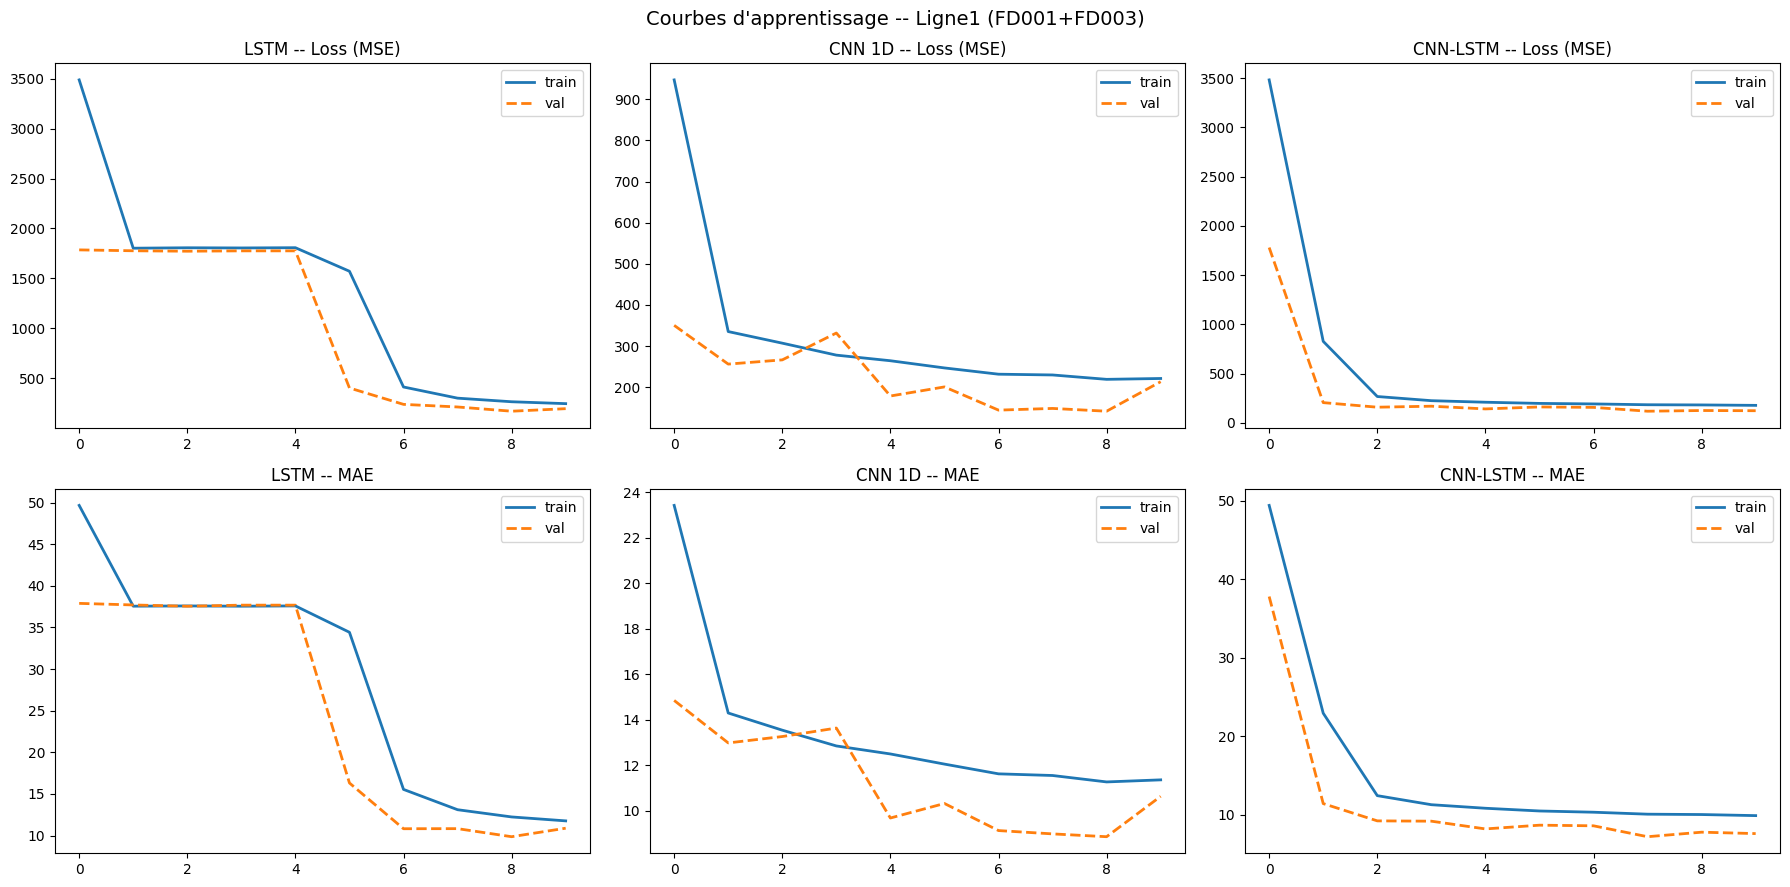

In [16]:
# Courbes d'apprentissage
import matplotlib.pyplot as plt

# Recuperation automatique des historiques si la cellule d'entrainement
 # a ete executee mais sans variable 'histories' en memoire.
if 'histories' not in globals() or not histories:
    recovered = {}
    model_map = [
        ('LSTM', 'model_lstm'),
        ('CNN 1D', 'model_cnn'),
        ('CNN-LSTM', 'model_cnn_lstm'),
    ]
    for name, var_name in model_map:
        model_obj = globals().get(var_name)
        model_hist = getattr(model_obj, 'history', None) if model_obj is not None else None
        if model_hist is not None and hasattr(model_hist, 'history') and model_hist.history:
            recovered[name] = model_hist

    if recovered:
        histories = recovered
    else:
        raise NameError(
            "'histories' est introuvable. Execute les cellules dans cet ordre : "
            "1) Construction des sequences temporelles, "
            "2) Definition des modeles, "
            "3) Entrainement des modeles."
        )

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, name in enumerate(['LSTM', 'CNN 1D', 'CNN-LSTM']):
    if name not in histories:
        raise KeyError(f"Historique manquant pour {name}. Reexecute la cellule 'Entrainement des modeles'.")
    h = histories[name]
    axes[0, col].plot(h.history['loss'],     label='train', lw=2)
    axes[0, col].plot(h.history['val_loss'], label='val',   lw=2, linestyle='--')
    axes[0, col].set_title(f'{name} -- Loss (MSE)')
    axes[0, col].legend()
    axes[1, col].plot(h.history['mae'],     label='train', lw=2)
    axes[1, col].plot(h.history['val_mae'], label='val',   lw=2, linestyle='--')
    axes[1, col].set_title(f'{name} -- MAE')
    axes[1, col].legend()

plt.suptitle(f"Courbes d'apprentissage -- {LIGNE} ({label})", fontsize=14)
plt.tight_layout()
plt.show()

──────────────────────────────────────────────────────────────────
  Modele           Split        RMSE      MAE       R2
──────────────────────────────────────────────────────────────────
  LSTM             train       13.27    10.10   0.9000
                   TEST        17.37    11.84   0.8078
  ──────────────────────────────────────────────────────────────
  CNN 1D           train       12.80    10.09   0.9070
                   TEST        14.57    10.38   0.8648
  ──────────────────────────────────────────────────────────────
  CNN-LSTM         train       10.56     7.49   0.9367
                   TEST        14.11     9.93   0.8732
  ──────────────────────────────────────────────────────────────
  Random Forest    train        5.66     4.12   0.9818
                   TEST        16.12    12.19   0.8346
  ──────────────────────────────────────────────────────────────


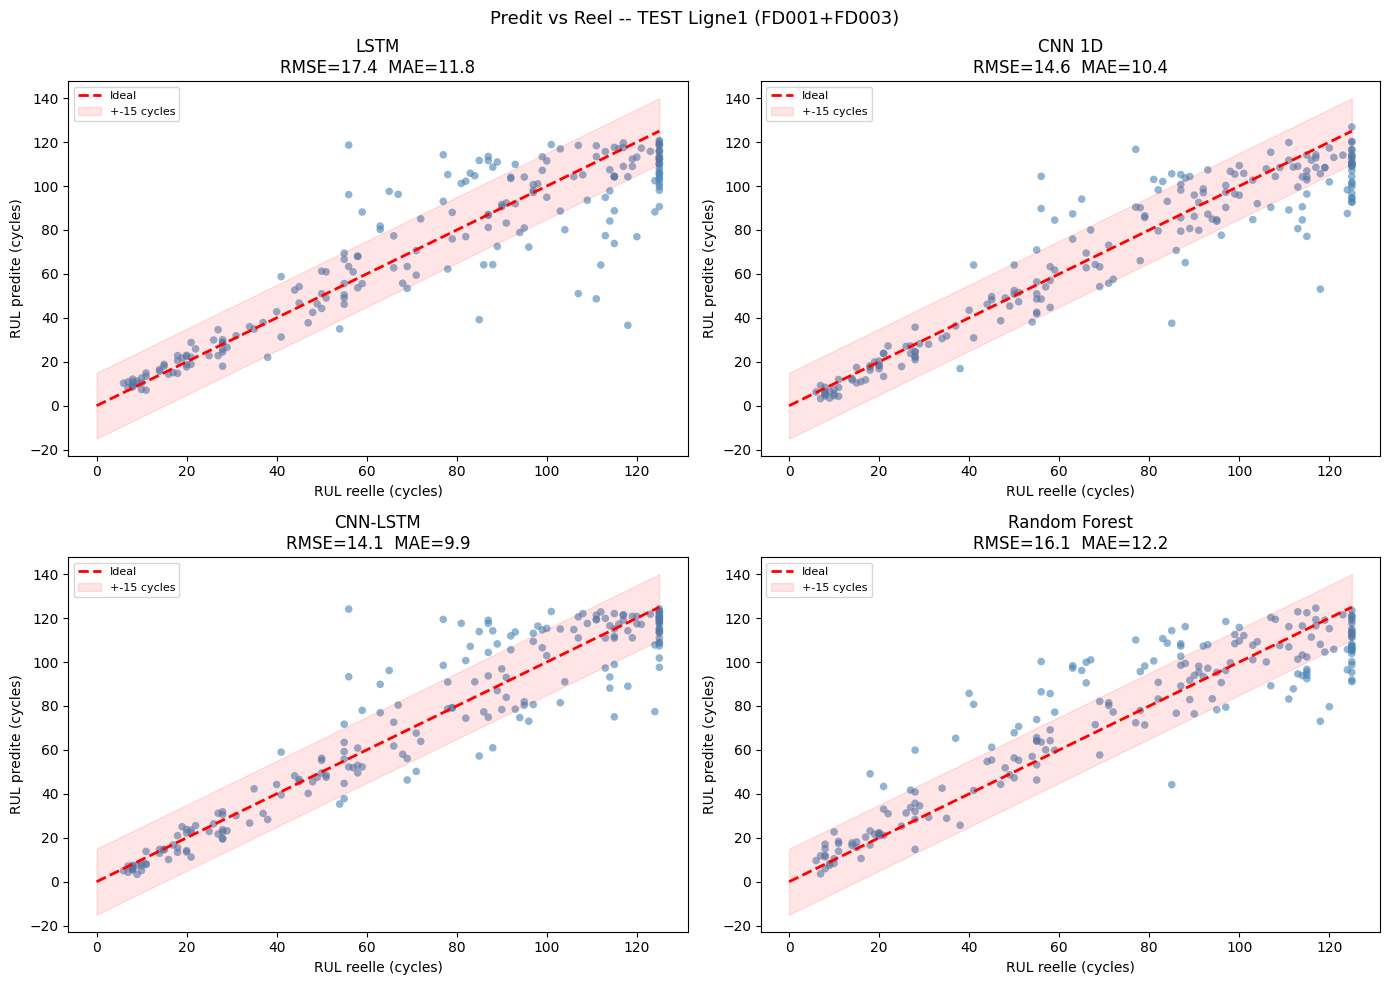

In [17]:
# Evaluation + Visualisation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y):
    try:
        y_pred = model.predict(X, verbose=0).flatten()  # modeles Keras
    except TypeError:
        y_pred = model.predict(X).flatten()             # modeles sklearn
    return {
        'RMSE' : np.sqrt(mean_squared_error(y, y_pred)),
        'MAE'  : mean_absolute_error(y, y_pred),
        'R2'   : r2_score(y, y_pred),
        'preds': y_pred
    }

results = {}
print(f"{'─'*66}")
print(f"  {'Modele':<16} {'Split':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print(f"{'─'*66}")

models_to_eval = [
    ('LSTM', model_lstm, X_train_m, X_test_m),
    ('CNN 1D', model_cnn, X_train_m, X_test_m),
    ('CNN-LSTM', model_cnn_lstm, X_train_m, X_test_m),
    ('Random Forest', model_rf, X_train_rf, X_test_rf),
]

for name, model, Xtr, Xte in models_to_eval:
    tr = evaluate(model, Xtr, y_train_m)
    te = evaluate(model, Xte, y_test_m)
    results[name] = te['preds']
    print(f"  {name:<16} {'train':<8} {tr['RMSE']:>8.2f} {tr['MAE']:>8.2f} {tr['R2']:>8.4f}")
    print(f"  {'':<16} {'TEST':<8} {te['RMSE']:>8.2f} {te['MAE']:>8.2f} {te['R2']:>8.4f}")
    print(f"  {'─'*62}")

model_names = ['LSTM', 'CNN 1D', 'CNN-LSTM', 'Random Forest']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flatten(), model_names):
    y_pred = results[name]
    rmse   = np.sqrt(mean_squared_error(y_test_m, y_pred))
    mae    = mean_absolute_error(y_test_m, y_pred)
    ax.scatter(y_test_m, y_pred, alpha=0.6, s=30, color='steelblue', edgecolors='none')
    ax.plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Ideal')
    ax.fill_between([0, RUL_MAX], [-15, RUL_MAX-15], [15, RUL_MAX+15],
                    alpha=0.1, color='red', label='+-15 cycles')
    ax.set_title(f'{name}\nRMSE={rmse:.1f}  MAE={mae:.1f}')
    ax.set_xlabel('RUL reelle (cycles)')
    ax.set_ylabel('RUL predite (cycles)')
    ax.legend(fontsize=8)

plt.suptitle(f'Predit vs Reel -- TEST {LIGNE} ({label})', fontsize=13)
plt.tight_layout()
plt.show()

## Baseline/Classification/Conclusion

Ici ajoute :
- baseline de regression simple (Linear Regression)
- classification binaire normal / a risque
- conclusion orientee metier

In [18]:
# Baseline regression simple (obligatoire roadmap)
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_rf, y_train_m)

y_pred_lr = linreg.predict(X_test_rf)
rmse_lr = np.sqrt(mean_squared_error(y_test_m, y_pred_lr))
mae_lr = mean_absolute_error(y_test_m, y_pred_lr)
r2_lr = r2_score(y_test_m, y_pred_lr)

print('Linear Regression -- TEST')
print(f'RMSE: {rmse_lr:.2f} | MAE: {mae_lr:.2f} | R2: {r2_lr:.4f}')

# Injecte la baseline dans les objets existants pour reutiliser les cellules suivantes
if 'results' not in globals():
    results = {}
results['Linear Regression'] = y_pred_lr

print('Baseline ajoutee a results sous la cle: Linear Regression')

Linear Regression -- TEST
RMSE: 51.68 | MAE: 22.41 | R2: -0.7009
Baseline ajoutee a results sous la cle: Linear Regression


Classification risque (seuil RUL <= 30)
Accuracy: 0.935 | Precision: 0.921 | Recall: 0.778 | F1: 0.843


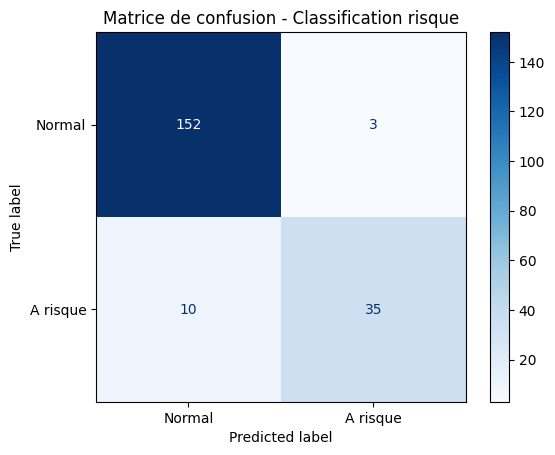

In [19]:
# Classification binaire: normal vs a risque (RUL <= seuil)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

RISK_THRESHOLD = 30
y_train_cls = (y_train_m <= RISK_THRESHOLD).astype(int)
y_test_cls = (y_test_m <= RISK_THRESHOLD).astype(int)

clf_risk = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf_risk.fit(X_train_rf, y_train_cls)
y_pred_cls = clf_risk.predict(X_test_rf)

acc = accuracy_score(y_test_cls, y_pred_cls)
prec = precision_score(y_test_cls, y_pred_cls, zero_division=0)
rec = recall_score(y_test_cls, y_pred_cls, zero_division=0)
f1 = f1_score(y_test_cls, y_pred_cls, zero_division=0)

print(f'Classification risque (seuil RUL <= {RISK_THRESHOLD})')
print(f'Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}')

cm = confusion_matrix(y_test_cls, y_pred_cls)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'A risque']).plot(cmap='Blues')
plt.title('Matrice de confusion - Classification risque')
plt.show()

In [21]:
# Conclusion orientee metier
if 'results' not in globals() or len(results) == 0:
    raise RuntimeError('results est vide. Execute la cellule Evaluation + Visualisation avant la conclusion.')

summary_rows = []
for model_name, preds in results.items():
    summary_rows.append({
        'Modele': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test_m, preds)),
        'MAE': mean_absolute_error(y_test_m, preds),
        'R2': r2_score(y_test_m, preds),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)
best_model = summary_df.iloc[0]

print('=' * 62)
print('Conclusion (RUL - TEST)')
print('=' * 62)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print('-' * 62)
print(f"Meilleur modele (RMSE): {best_model['Modele']} | RMSE={best_model['RMSE']:.2f} | MAE={best_model['MAE']:.2f}")
print('Recommendation metier: prioriser ce modele pour un prototype d alerte maintenance,')
print('puis valider sa stabilite sur plusieurs runs avant industrialisation.')
print('=' * 62)

display(summary_df)

Conclusion (RUL - TEST)
           Modele   RMSE    MAE     R2
         CNN-LSTM 14.109  9.928  0.873
           CNN 1D 14.571 10.379  0.865
    Random Forest 16.116 12.194  0.835
             LSTM 17.373 11.840  0.808
Linear Regression 51.677 22.406 -0.701
--------------------------------------------------------------
Meilleur modele (RMSE): CNN-LSTM | RMSE=14.11 | MAE=9.93
Recommendation metier: prioriser ce modele pour un prototype d alerte maintenance,
puis valider sa stabilite sur plusieurs runs avant industrialisation.


,Modele,RMSE,MAE,R2
0,CNN-LSTM,14.108923,9.927560,0.873213
1,CNN 1D,14.570724,10.378552,0.864777
2,Random Forest,16.115665,12.194000,0.834581
3,LSTM,17.373346,11.839972,0.807755
4,Linear Regression,51.677411,22.405697,-0.700943


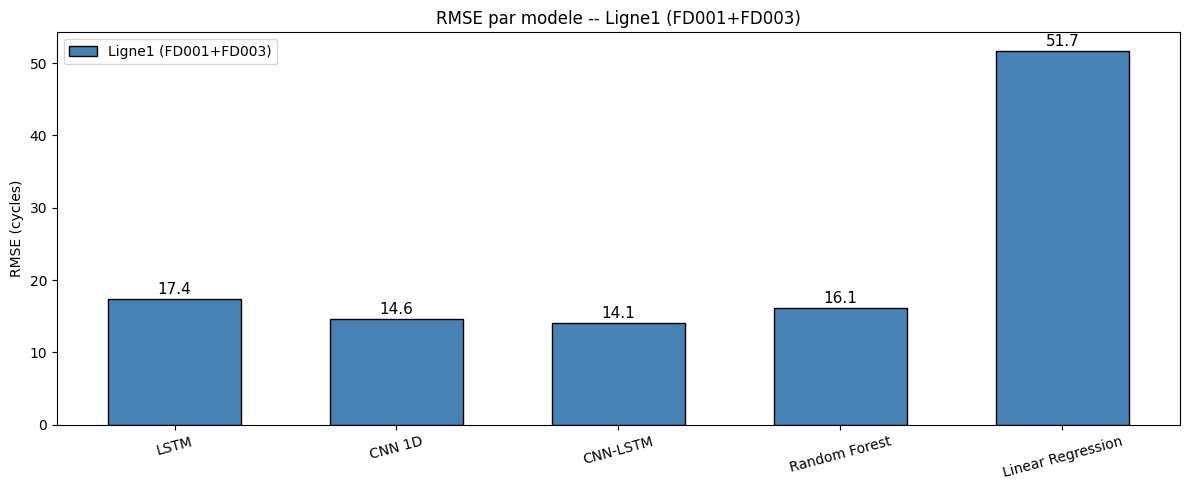

In [22]:
# Comparaison RMSE entre les modeles
if 'results' not in globals() or not results:
    raise RuntimeError("results est vide. Execute d'abord la cellule Evaluation + Visualisation.")

#Ici on Utilise automatiquement tous les modeles disponibles (incluant Linear Regression)
modeles = list(results.keys())
rmse_merged = [np.sqrt(mean_squared_error(y_test_m, results[n])) for n in modeles]

x     = np.arange(len(modeles))
width = 0.6

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, rmse_merged, width, color='steelblue', edgecolor='black',
              label=f'{LIGNE} ({label})')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(modeles, rotation=15)
ax.set_ylabel('RMSE (cycles)')
ax.set_title(f'RMSE par modele -- {LIGNE} ({label})')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Sauvegarde et export
from joblib import dump

if 'results' not in globals() or not results:
    raise RuntimeError("results est vide. Execute d'abord la cellule Evaluation + Visualisation.")

model_lstm.save(f'model_lstm_{LIGNE}.keras')
model_cnn.save(f'model_cnn_{LIGNE}.keras')
model_cnn_lstm.save(f'model_cnn_lstm_{LIGNE}.keras')
dump(model_rf, f'model_rf_{LIGNE}.joblib')
print(f"Modeles sauvegardes -- {LIGNE}")

unit_ids = list(df_test_m.groupby('unit_id').groups.keys())
pred_df  = pd.DataFrame({
    'unit_id'   : unit_ids,
    'source'    : df_test_m.groupby('unit_id')['source'].first().values,
    'RUL_vraie' : y_test_m,
})

# Mapping flexible pour inclure aussi Linear Regression
pred_map = {
    'LSTM': 'RUL_pred_LSTM',
    'CNN 1D': 'RUL_pred_CNN',
    'CNN-LSTM': 'RUL_pred_hybrid',
    'Random Forest': 'RUL_pred_RF',
    'Linear Regression': 'RUL_pred_LR',
}

for model_name, pred_col in pred_map.items():
    if model_name in results:
        pred_df[pred_col] = results[model_name]
        err_col = pred_col.replace('RUL_pred', 'err')
        pred_df[err_col] = (pred_df['RUL_vraie'] - pred_df[pred_col]).abs()

fname = f"predictions_{LIGNE}_{label.replace('+','_')}.xlsx"
pred_df.to_excel(fname, index=False)
print(f"{fname} sauvegarde.\n")

print(f"{'='*50}")
print(f"  RESUME FINAL -- {LIGNE} ({label})")
print(f"{'='*50}")
for err_col in [c for c in pred_df.columns if c.startswith('err_')]:
    model_name = (
        err_col.replace('err_', '')
        .replace('hybrid', 'CNN-LSTM')
        .replace('RF', 'Random Forest')
        .replace('LR', 'Linear Regression')
    )
    print(f"  {model_name:<17} MAE moy : {pred_df[err_col].mean():.2f}  |  erreur max : {pred_df[err_col].max():.0f} cycles")
print(f"{'='*50}")
display(pred_df.head(10))

Modeles sauvegardes -- Ligne1
predictions_Ligne1_FD001_FD003.xlsx sauvegarde.

  RESUME FINAL -- Ligne1 (FD001+FD003)
  LSTM              MAE moy : 11.84  |  erreur max : 81 cycles
  CNN               MAE moy : 10.38  |  erreur max : 65 cycles
  CNN-LSTM          MAE moy : 9.93  |  erreur max : 68 cycles
  Random Forest     MAE moy : 12.19  |  erreur max : 46 cycles
  Linear Regression MAE moy : 22.41  |  erreur max : 359 cycles


,unit_id,source,RUL_vraie,RUL_pred_LSTM,err_LSTM,RUL_pred_CNN,err_CNN,RUL_pred_hybrid,err_hybrid,RUL_pred_RF,err_RF,RUL_pred_LR,err_LR
0,1,FD001,112.0,64.069275,47.930725,108.632278,3.367722,122.834145,10.834145,87.80,24.20,-218.081567,330.081567
1,2,FD001,98.0,101.001701,3.001701,106.678261,8.678261,116.380760,18.380760,99.68,1.68,64.666270,33.333730
2,3,FD001,69.0,63.370991,5.629009,63.240158,5.759842,56.103535,12.896465,57.68,11.32,73.677486,4.677486
3,4,FD001,82.0,76.981293,5.018707,79.600578,2.399422,74.449440,7.550560,90.74,8.74,80.456875,1.543125
4,5,FD001,91.0,83.158508,7.841492,79.890221,11.109779,83.921509,7.078491,98.10,7.10,86.561238,4.438762
5,6,FD001,93.0,109.856415,16.856415,107.348129,14.348129,113.691696,20.691696,107.90,14.90,98.585549,5.585549
6,7,FD001,91.0,92.276810,1.276810,92.501740,1.501740,93.012604,2.012604,95.44,4.44,95.504265,4.504265
7,8,FD001,95.0,104.097763,9.097763,84.654938,10.345062,80.347107,14.652893,95.24,0.24,90.598486,4.401514
8,9,FD001,111.0,113.381798,2.381798,119.818825,8.818825,119.487778,8.487778,106.90,4.10,101.457522,9.542478
9,10,FD001,96.0,72.227768,23.772232,77.624519,18.375481,73.064087,22.935913,90.64,5.36,83.678287,12.321713
